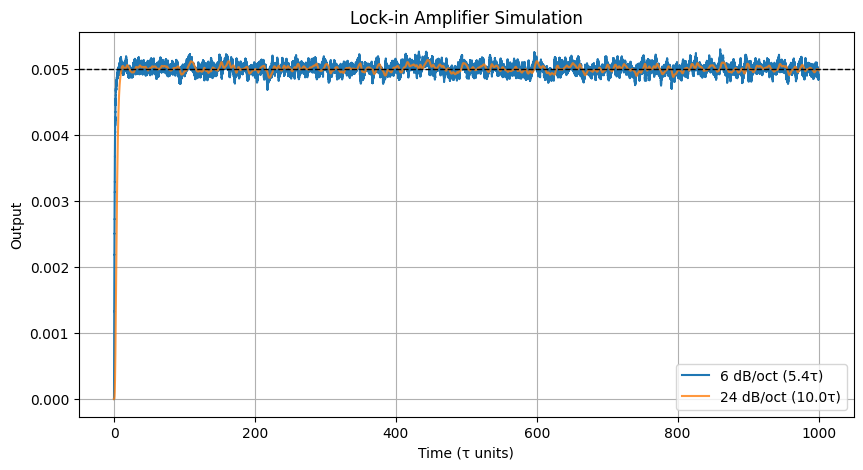

=== 收斂時間（單位 τ）===
6 dB/oct  ≈ 5.38 τ
24 dB/oct ≈ 9.97 τ


In [9]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt

# 訊號 + 雜訊
fs = 5000  # sampling rate
T = 1000      # total time (in tau units later)
t = np.linspace(0, T, fs * T)
tau = 1.0  # normalize time constant
f0 = 1000     # signal frequency (Hz)

# signal
Vs = 10e-3 * np.sin(2 * np.pi * f0 * t)

# noise（拿掉原本講義上60Hz干擾）
Vn = 10e-3 * np.random.randn(len(t))
V_in = Vs + Vn

# Mixingggggg
ref = np.sin(2 * np.pi * f0 * t)  # reference oscillator
mixed = V_in * ref  # lock-in multiplication


# 模組三：RC 低通濾波
def rc_lowpass(x, tau, dt):
    alpha = dt / (tau + dt)
    y = np.zeros_like(x)
    for i in range(1, len(x)):
        y[i] = y[i-1] + alpha * (x[i] - y[i-1])
    return y

def cascaded_rc(x, tau, dt, n=4):
    y = x.copy()
    for _ in range(n):
        y = rc_lowpass(y, tau, dt)
    return y

dt = t[1] - t[0]

# 6 dB/oct
out_6db = rc_lowpass(mixed, tau, dt) #一階濾波

# 24 dB/oct
out_24db = cascaded_rc(mixed, tau, dt, n=4) #四階濾波

# 模擬 steady-state（找 99% 收斂時間）
def convergence_time(y, target, t, tol=0.01):
    for i in range(len(y)):
        if np.abs(y[i] - target) / np.abs(target) < tol:
            return t[i]
    return None

# 理論 DC 成分（lock-in after averaging）
target = np.mean(out_6db[int(len(t)*0.8):])
t6 = convergence_time(out_6db, target, t)
t24 = convergence_time(out_24db, target, t)

# 視覺化
plt.figure(figsize=(10,5))
plt.plot(t, out_6db, label=f'6 dB/oct ({t6/tau:.1f}τ)')
plt.plot(t, out_24db, label=f'24 dB/oct ({t24/tau:.1f}τ)', alpha=0.8)
plt.axhline(target, linestyle="--", color="black", linewidth=1)
plt.title("Lock-in Amplifier Simulation")
plt.xlabel("Time (τ units)")
plt.ylabel("Output")
#plt.ylim()
plt.legend()
plt.grid()
plt.show()

# 結果輸出
print("=== 收斂時間（單位 τ）===")
print(f"6 dB/oct  ≈ {t6:.2f} τ")
print(f"24 dB/oct ≈ {t24:.2f} τ")